<a href="https://colab.research.google.com/github/Pranav77774/concept-and-technology-of-AI/blob/main/2501565_PranavManSingh_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install & Import Libraries
!pip install -q scikit-learn==1.3.2 imbalanced-learn matplotlib pandas seaborn tensorflow==2.15.0 openpyxl joblib

import os, json, math, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (9,6)

# sklearn & imblearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# tensorflow / keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping




ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [ ]:
# Load Dataset & Save Provenance
DATA_PATH = "/content/drive/MyDrive/air_pollution.csv"

if not os.path.exists(DATA_PATH):
    print("Dataset not found at", DATA_PATH)
    from google.colab import files
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

prov = {
    "dataset_file": DATA_PATH,
    "loaded_at_utc": datetime.utcnow().isoformat(),
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1])
}
with open("dataset_provenance_classification.json", "w") as f:
    json.dump(prov, f, indent=2)
print("Saved dataset_provenance_classification.json")


Loaded: /content/drive/MyDrive/air_pollution.csv
Shape: (5000, 10)


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,NaN,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


Saved dataset_provenance_classification.json


In [ ]:
# Detect Target Column & Show Columns
print("Columns:", df.columns.tolist())
print("\nDtypes:")
display(df.dtypes)

# The target is "Air Quality" - a 4-class label indicating the overall air quality
# level at a given location/time: Good, Moderate, Poor, or Hazardous.
preferred_targets = ['Air Quality', 'air_quality', 'AirQuality', 'label', 'target', 'outcome']
target_col = None
for t in preferred_targets:
    if t in df.columns:
        target_col = t
        break
if target_col is None:
    target_col = df.columns[-1]
    print(target_col)
else:
    print(target_col)

print("\nTarget value counts (including NaNs):")
display(df[target_col].value_counts(dropna=False))


Columns: ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas', 'Population_Density', 'Air Quality']

Dtypes:


,0
Temperature,float64
Humidity,float64
PM2.5,float64
PM10,float64
NO2,float64
SO2,float64
CO,float64
Proximity_to_Industrial_Areas,float64
Population_Density,int64
Air Quality,object


Air Quality

Target value counts (including NaNs):


,count
Air Quality,
Good,2000
Moderate,1500
Poor,1000
Hazardous,500


Missing values per column:


,0
NO2,5
Humidity,4
Proximity_to_Industrial_Areas,4
Temperature,3
CO,3
PM10,3
SO2,2
PM2.5,0
Population_Density,0
Air Quality,0


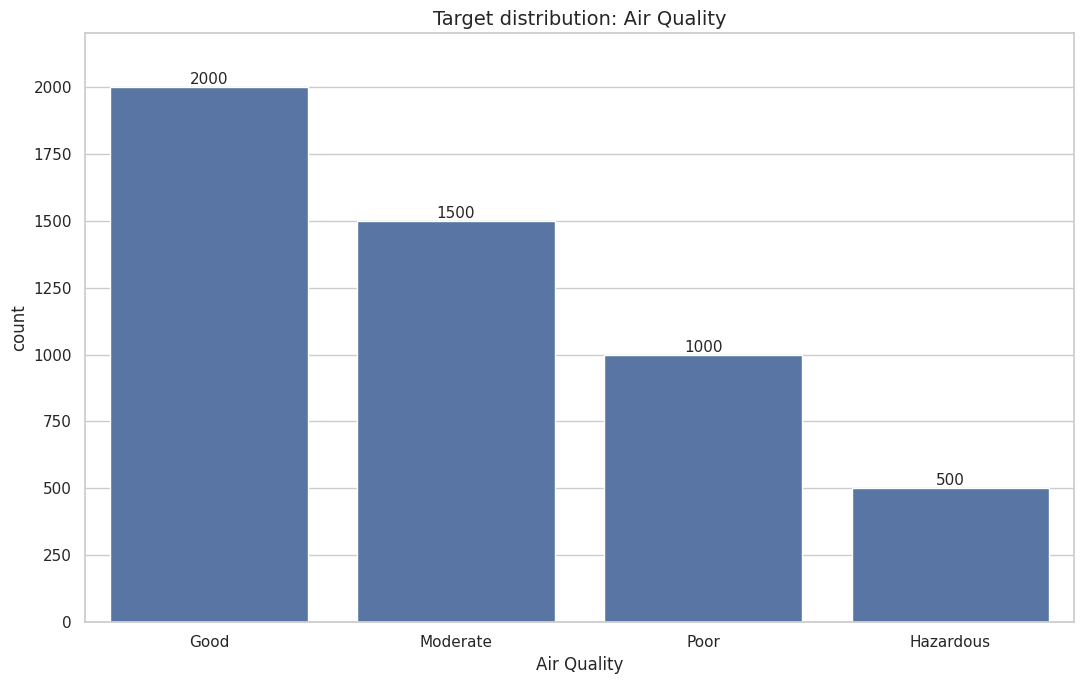

Numeric columns: ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas', 'Population_Density']


,count,mean,std,min,25%,50%,75%,max
Temperature,4997.0,30.032299,6.720747,13.40,25.10,29.00,34.000,58.60
Humidity,4996.0,70.052102,15.863600,36.00,58.30,69.80,80.300,128.10
PM2.5,5000.0,20.142140,24.554546,0.00,4.60,12.00,26.100,295.00
PM10,4997.0,30.209065,27.343621,-0.20,12.30,21.70,38.100,315.80
NO2,4995.0,26.409209,8.897144,7.40,20.10,25.30,31.900,64.90
SO2,4998.0,10.014726,6.751551,-6.20,5.10,8.00,13.775,44.90
CO,4997.0,1.500046,0.545939,0.65,1.03,1.41,1.840,3.72
Proximity_to_Industrial_Areas,4996.0,8.422878,3.608273,2.50,5.40,7.90,11.100,25.80
Population_Density,5000.0,497.423800,152.754084,188.00,381.00,494.00,600.000,957.00


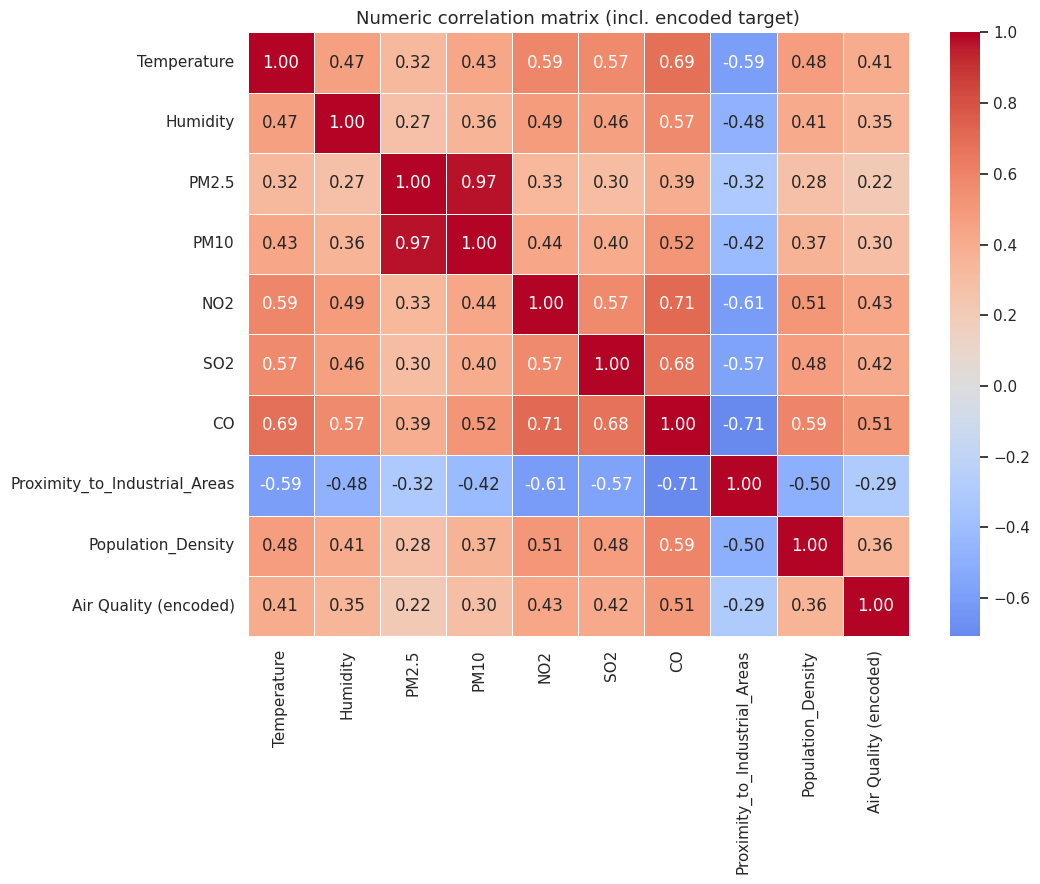

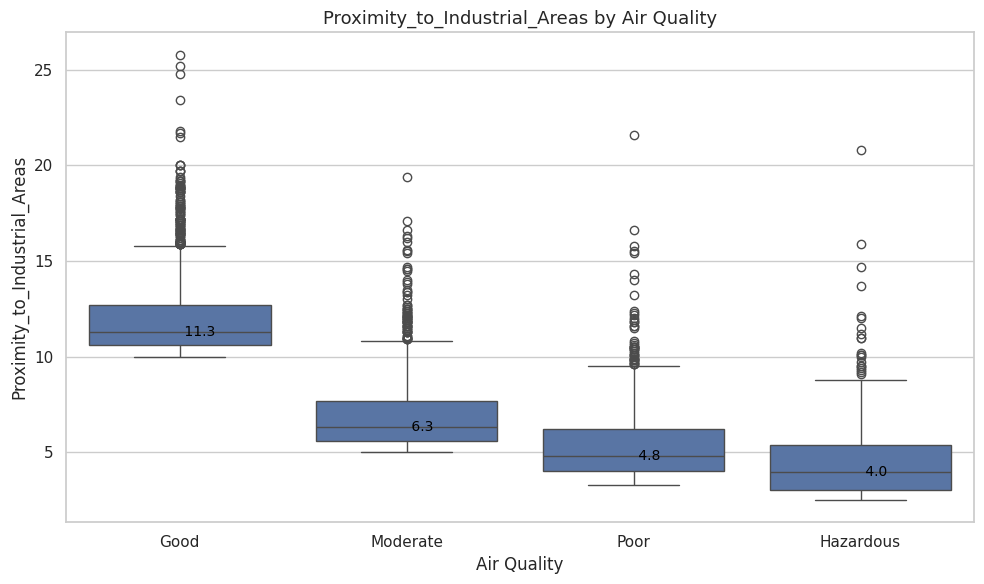

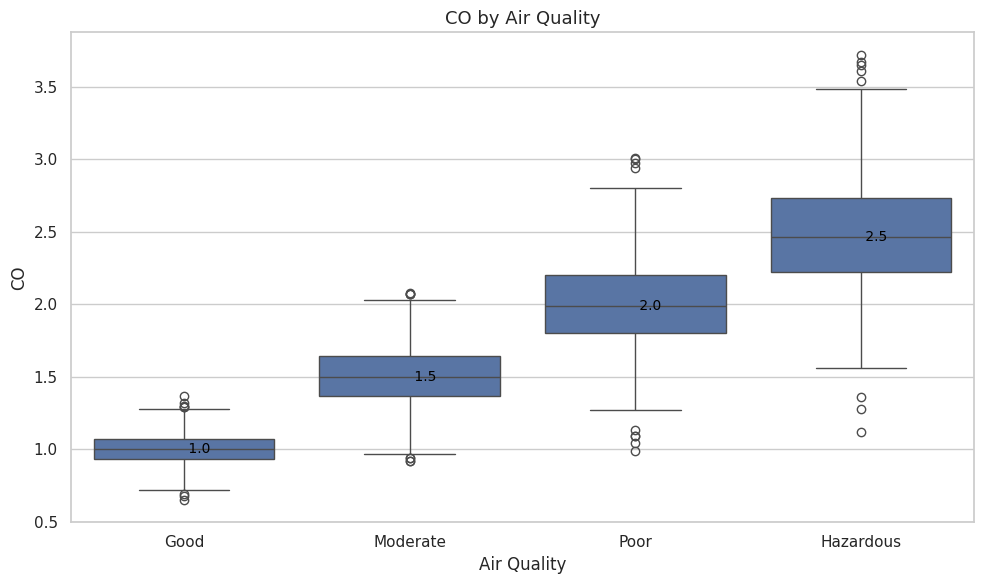

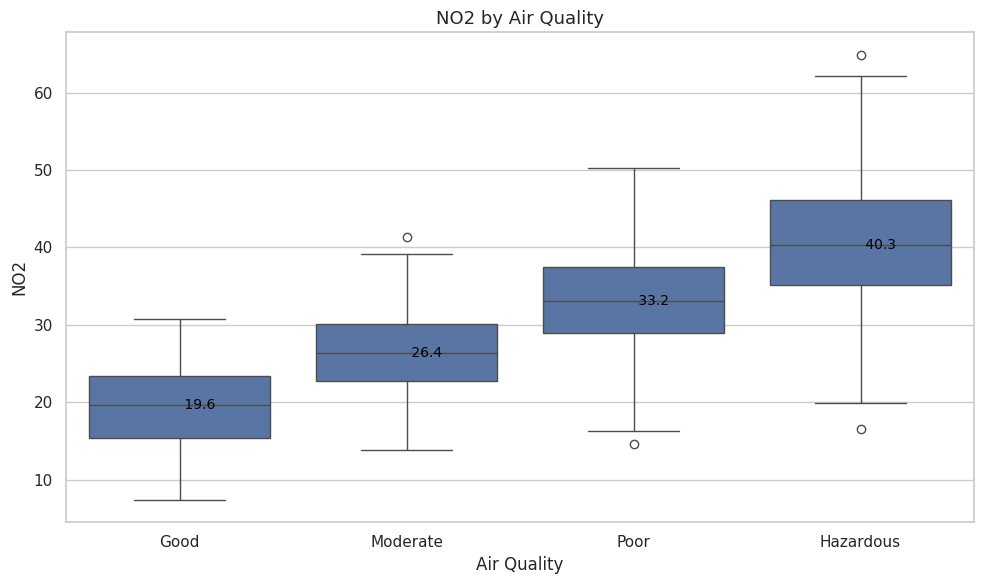

In [ ]:
# EDA (Missing Values & Target Distribution)
print("Missing values per column:")
display(df.isnull().sum().sort_values(ascending=False).head(50))

# Target distribution
plt.figure(figsize=(11,7))
ax = sns.countplot(x=target_col, data=df,
                   order=['Good','Moderate','Poor','Hazardous']
                         if set(['Good','Moderate','Poor','Hazardous']).issubset(df[target_col].unique())
                         else df[target_col].value_counts().index.tolist())
for container in ax.containers:
    ax.bar_label(container, fontsize=11)
plt.title(f"Target distribution: {target_col}", fontsize=14)
plt.margins(y=0.1)
plt.tight_layout()
plt.show()

# All 9 input features are numeric in this dataset - compute full correlation
# matrix including a label-encoded target so we can see which features are most
# predictive of air quality at a glance.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)
display(df[numeric_cols].describe().T)

corr_df = df[numeric_cols].copy()
corr_df[f"{target_col} (encoded)"] = pd.factorize(df[target_col])[0]

plt.figure(figsize=(11,9))
sns.heatmap(corr_df.corr(), center=0, cmap="coolwarm", annot=True, fmt=".2f",
            linewidths=0.5)
plt.title("Numeric correlation matrix (incl. encoded target)", fontsize=13)
plt.tight_layout()
plt.show()

# Boxplots for the top 3 most correlated features vs Air Quality
top_features_eda = ["Proximity_to_Industrial_Areas", "CO", "NO2"]
quality_order = ["Good","Moderate","Poor","Hazardous"]
quality_order = [q for q in quality_order if q in df[target_col].unique()]
for col in top_features_eda:
    if col not in df.columns:
        continue
    plt.figure(figsize=(10,6))
    sns.boxplot(x=target_col, y=col, data=df, order=quality_order)
    for i, cls in enumerate(quality_order):
        median = df[df[target_col]==cls][col].median()
        plt.text(i, median, f" {median:.1f}", va="center", fontsize=10, color="black")
    plt.title(f"{col} by {target_col}", fontsize=13)
    plt.tight_layout()
    plt.show()


In [ ]:
# Data Cleaning & Preparing Features (X) and Target (y)

# No date columns, no ID columns, and no leakage-prone columns in this dataset -
# all 9 numeric sensor/environmental readings are genuine pre-measurement features.
# Minor missing values (3-5 per column) will be handled by median imputation
# in the preprocessing pipeline, so we don't need to drop any rows here.

# Drop exact duplicate rows if any
n_dup = df.duplicated().sum()
if n_dup > 0:
    print("Dropping duplicates:", n_dup)
    df = df.drop_duplicates().reset_index(drop=True)
else:
    print("No duplicates found.")

# Drop rows with missing target (none expected, but safe-guard)
n_target_nan = df[target_col].isnull().sum()
if n_target_nan > 0:
    print("Dropping rows with missing target:", n_target_nan)
    df = df.dropna(subset=[target_col]).reset_index(drop=True)

# Separate features and target
X = df.drop(columns=[target_col]).copy()
y_raw = df[target_col].copy()

# Encode target: Good=0, Hazardous=1, Moderate=2, Poor=3 (alphabetical by LabelEncoder)
# but we keep the mapping transparent so the classification report is readable.
label_encoder = LabelEncoder()
if not pd.api.types.is_numeric_dtype(y_raw):
    y = label_encoder.fit_transform(y_raw)
    classes = list(label_encoder.classes_)
    print("Encoded target classes:", classes)
else:
    unique_vals = np.unique(y_raw)
    if len(unique_vals) <= 10 and np.all(np.equal(np.mod(unique_vals,1), 0)):
        y = y_raw.astype(int).values
        classes = list(np.unique(y))
        print("Numeric discrete classes detected:", classes)
    else:
        print("Continuous target detected; binning into 3 classes (low/medium/high).")
        y_binned = pd.qcut(y_raw.rank(method="first"), 3, labels=["low","medium","high"])
        y = label_encoder.fit_transform(y_binned)
        classes = list(label_encoder.classes_)
        print("Binned classes:", classes)

print("Final dataset shape:", X.shape, "Labels shape:", y.shape)
print("Feature columns:", X.columns.tolist())


No duplicates found.
Encoded target classes: ['Good', 'Hazardous', 'Moderate', 'Poor']
Final dataset shape: (5000, 9) Labels shape: (5000,)
Feature columns: ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas', 'Population_Density']


In [ ]:
# Train-Test Split & Pipeline Setup
# Detect numeric and categorical features automatically
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object','category','bool']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Fit preprocessor to compute transformed feature names
preprocessor.fit(X)
# build transformed feature names list
transformed_names = numeric_features.copy()
if categorical_features:
    ohe = preprocessor.named_transformers_['cat'].named_steps['ohe']
    cat_names = list(ohe.get_feature_names_out(categorical_features))
    transformed_names += cat_names
print("Transformed feature count:", len(transformed_names))


Numeric features: ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas', 'Population_Density']
Categorical features: []
Transformed feature count: 9


In [ ]:
# Train Baseline Models (Logistic Regression & Random Forest)
from collections import Counter
counter = Counter(y)
print("Class counts:", counter)
counts = np.array(list(counter.values()))
imbalance_ratio = counts.max() / counts.min() if counts.min() > 0 else np.inf
print("Imbalance ratio (max/min):", round(imbalance_ratio,2))

# Use SMOTE when imbalance ratio >= 2 (i.e. the largest class has at least 2x
# as many samples as the smallest). This is intentionally lower than the old
# threshold of >4 so that a 4:1 ratio (like Good:Hazardous here) correctly
# triggers oversampling of the minority class during training.
use_smote = False
if imbalance_ratio >= 2 or any(counts < 0.15 * len(y)):
    use_smote = True
    print("Class imbalance detected - using SMOTE during training.")
else:
    print("Classes are balanced - SMOTE not necessary.")


Class counts: Counter({np.int64(0): 2000, np.int64(2): 1500, np.int64(3): 1000, np.int64(1): 500})
Imbalance ratio (max/min): 4.0
Class imbalance detected - using SMOTE during training.


In [ ]:
#stratified split and baseline models
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Train/test shapes:", X_train.shape, X_test.shape)

# Pipelines: include SMOTE in training pipeline if flagged
if use_smote:
    log_pipe = ImbPipeline(steps=[('pre', preprocessor), ('smote', SMOTE(random_state=42)), ('clf', LogisticRegression(max_iter=1000))])
    rf_pipe = ImbPipeline(steps=[('pre', preprocessor), ('smote', SMOTE(random_state=42)), ('clf', RandomForestClassifier(random_state=42))])
else:
    log_pipe = Pipeline(steps=[('pre', preprocessor), ('clf', LogisticRegression(max_iter=1000))])
    rf_pipe = Pipeline(steps=[('pre', preprocessor), ('clf', RandomForestClassifier(random_state=42))])

# Fit baselines
log_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

def eval_clf(y_true, y_pred, avg='weighted'):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average=avg, zero_division=0),
        'recall': recall_score(y_true, y_pred, average=avg, zero_division=0),
        'f1': f1_score(y_true, y_pred, average=avg, zero_division=0)
    }

y_pred_log = log_pipe.predict(X_test)
y_pred_rf = rf_pipe.predict(X_test)

print("Logistic baseline:", eval_clf(y_test, y_pred_log))
print("RandomForest baseline:", eval_clf(y_test, y_pred_rf))


Train/test shapes: (4000, 9) (1000, 9)
Logistic baseline: {'accuracy': 0.931, 'precision': 0.9307649764818545, 'recall': 0.931, 'f1': 0.930804871012606}
RandomForest baseline: {'accuracy': 0.95, 'precision': 0.9497317101571551, 'recall': 0.95, 'f1': 0.9498520305311808}


In [ ]:
#hyperparameter tuning (stratified CV)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic grid (note: if using ImbPipeline names will be 'clf__param')
param_grid_log = {
    'clf__C': [0.01, 0.1, 1, 10]
}
gs_log = GridSearchCV(log_pipe, param_grid_log, cv=cv, scoring='f1_weighted', n_jobs=-1)
print("Tuning Logistic Regression...")
gs_log.fit(X_train, y_train)
print("Best logistic params:", gs_log.best_params_, "Best CV f1:", gs_log.best_score_)

# RandomForest grid
param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 8, 16],
    'clf__min_samples_split': [2, 5]
}
gs_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=cv, scoring='f1_weighted', n_jobs=-1)
print("Tuning RandomForest (may take longer)...")
gs_rf.fit(X_train, y_train)
print("Best RF params:", gs_rf.best_params_, "Best CV f1:", gs_rf.best_score_)


Tuning Logistic Regression...
Best logistic params: {'clf__C': 10} Best CV f1: 0.9372133303862021
Tuning RandomForest (may take longer)...
Best RF params: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 100} Best CV f1: 0.9523033903565304


In [ ]:

# Transform training and test sets
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)
if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()
    X_test_trans = X_test_trans.toarray()

# (A) SelectKBest using ANOVA (f_classif). Cap k at a generous fraction of the total
# transformed feature count (after one-hot encoding) so we don't throw away useful
# signal - 12 was fine for a small healthcare feature set, but is too restrictive
# once categorical columns like job/month/poutcome expand into dozens of dummy columns.
k = min(max(20, int(0.5 * X_train_trans.shape[1])), X_train_trans.shape[1])
skb = SelectKBest(score_func=f_classif, k=k)
skb.fit(X_train_trans, y_train)
top_idx = np.argsort(skb.scores_)[-k:][::-1]
top_features = [transformed_names[i] for i in top_idx]
print("SelectKBest top features:", top_features)

# (B) Embedded selection with RF on full transformed train data
rf_emb = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_emb.fit(X_train_trans, y_train)
sfm = SelectFromModel(rf_emb, threshold='median')  # keep features above median importance
sfm.fit(X_train_trans, y_train)
sfm_features = [name for name, keep in zip(transformed_names, sfm.get_support()) if keep]
print("Embedded RF features:", sfm_features)

# Union (not intersection): taking the intersection of two independent selection
# methods can be overly aggressive and accidentally drop genuinely predictive
# features (e.g. age, balance) that only one method flagged as important. Taking
# the union keeps anything either method considered useful, which is safer.
selected_features = sorted(set(top_features) | set(sfm_features), key=transformed_names.index)
if not selected_features:
    selected_features = top_features
print("Final selected features:", selected_features)

selected_indices = [transformed_names.index(f) for f in selected_features]
X_train_sel = X_train_trans[:, selected_indices]
X_test_sel = X_test_trans[:, selected_indices]
print("Selected matrices shape:", X_train_sel.shape, X_test_sel.shape)


SelectKBest top features: ['CO', 'Proximity_to_Industrial_Areas', 'NO2', 'Temperature', 'SO2', 'Population_Density', 'Humidity', 'PM10', 'PM2.5']
Embedded RF features: ['Temperature', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas']
Final selected features: ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas', 'Population_Density']
Selected matrices shape: (4000, 9) (1000, 9)


In [ ]:

# Extract best hyperparams from GridSearch results
best_log_params = gs_log.best_params_
best_rf_params = gs_rf.best_params_

# Convert keys like 'clf__C' -> 'C'
log_params_clean = {k.split('__')[-1]: v for k,v in best_log_params.items()}
rf_params_clean = {k.split('__')[-1]: v for k,v in best_rf_params.items()}

# Final Logistic
final_log = LogisticRegression(**log_params_clean, max_iter=2000, random_state=42)
final_log.fit(X_train_sel, y_train)
y_pred_log_final = final_log.predict(X_test_sel)
print("Final Logistic:", eval_clf(y_test, y_pred_log_final))

# Final RandomForest
final_rf = RandomForestClassifier(random_state=42, **rf_params_clean)
final_rf.fit(X_train_sel, y_train)
y_pred_rf_final = final_rf.predict(X_test_sel)
print("Final RandomForest:", eval_clf(y_test, y_pred_rf_final))

# Reports
print("\nClassification report - RandomForest (final):\n", classification_report(y_test, y_pred_rf_final, zero_division=0))
cm = confusion_matrix(y_test, y_pred_rf_final)
print("Confusion matrix (rows=true, cols=pred):\n", cm)


Final Logistic: {'accuracy': 0.931, 'precision': 0.9308895295234892, 'recall': 0.931, 'f1': 0.9306200815981002}
Final RandomForest: {'accuracy': 0.95, 'precision': 0.9498320829825307, 'recall': 0.95, 'f1': 0.9496390989323839}

Classification report - RandomForest (final):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.90      0.81      0.85       100
           2       0.96      0.97      0.96       300
           3       0.87      0.89      0.88       200

    accuracy                           0.95      1000
   macro avg       0.93      0.92      0.92      1000
weighted avg       0.95      0.95      0.95      1000

Confusion matrix (rows=true, cols=pred):
 [[400   0   0   0]
 [  0  81   0  19]
 [  1   0 291   8]
 [  0   9  13 178]]


Num classes: 4


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,852 (11.14 KB)

 Trainable params: 2,852 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6415 - loss: 0.8396 - val_accuracy: 0.8133 - val_loss: 0.4934
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8297 - loss: 0.4360 - val_accuracy: 0.9017 - val_loss: 0.3188
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8665 - loss: 0.3251 - val_accuracy: 0.9167 - val_loss: 0.2538
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8906 - loss: 0.2767 - val_accuracy: 0.9183 - val_loss: 0.2276
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8968 - loss: 0.2549 - val_accuracy: 0.9267 - val_loss: 0.2081
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9041 - loss: 0.2373 - val_accuracy: 0.9233 - val_loss: 0.1982
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9082 - loss: 0.2272 - val_accuracy: 0.9333 - val_loss: 0.1871
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9126 - loss: 0.2180 - val_acc

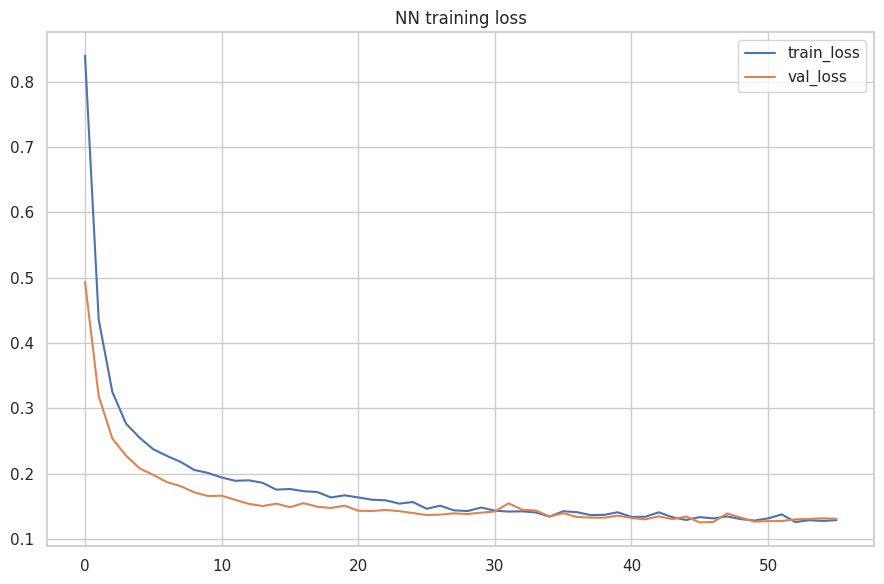

In [ ]:

scaler_sel = StandardScaler()
X_train_nn = scaler_sel.fit_transform(X_train_sel)
X_test_nn = scaler_sel.transform(X_test_sel)

num_classes = len(np.unique(y))
print("Num classes:", num_classes)

nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])
nn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
nn.summary()

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
history = nn.fit(X_train_nn, y_train, validation_split=0.15, epochs=100, batch_size=32, callbacks=[es], verbose=1)

# Evaluate
y_prob_nn = nn.predict(X_test_nn)
y_pred_nn = np.argmax(y_prob_nn, axis=1)
print("NN metrics:", eval_clf(y_test, y_pred_nn))
print("\nNN classification report:\n", classification_report(y_test, y_pred_nn, zero_division=0))

# Plot training loss
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("NN training loss")
plt.tight_layout()
plt.show()


In [ ]:

# Feature importance from final_rf
feat_imp = pd.Series(final_rf.feature_importances_, index=selected_features).sort_values(ascending=False)
print("RandomForest importances:")
display(feat_imp)

# Permutation importance (may take some time)
from sklearn.inspection import permutation_importance
perm = permutation_importance(final_rf, X_test_sel, y_test, n_repeats=20, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=selected_features).sort_values(ascending=False)
print("Permutation importances (mean):")
display(perm_imp)

# Save models and artifacts
joblib.dump(final_rf, "final_rf_classifier.joblib")
joblib.dump(final_log, "final_logistic_classifier.joblib")
joblib.dump(scaler_sel, "scaler_selected_features.joblib")
nn.save("final_nn_classifier.keras")

summary = {
    "dataset_path": DATA_PATH,
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "target": target_col,
    "classes": int(num_classes),
    "selected_features": selected_features,
    "rf_final_metrics": eval_clf(y_test, y_pred_rf_final),
    "log_final_metrics": eval_clf(y_test, y_pred_log_final),
    "nn_metrics": eval_clf(y_test, y_pred_nn),
    "rf_best_params": gs_rf.best_params_,
    "log_best_params": gs_log.best_params_,
    "saved_at_utc": datetime.utcnow().isoformat()
}
with open("project_summary_classification.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved models and summary JSON.")
display(pd.DataFrame([summary['rf_final_metrics'], summary['log_final_metrics'], summary['nn_metrics']],
                     index=['RF_final','Logistic_final','NN_final']))


RandomForest importances:


,0
CO,0.349371
Proximity_to_Industrial_Areas,0.287448
NO2,0.094816
SO2,0.093198
Temperature,0.069873
Population_Density,0.037123
Humidity,0.036483
PM10,0.021476
PM2.5,0.010212


Permutation importances (mean):


,0
CO,0.34825
Proximity_to_Industrial_Areas,0.29840
NO2,0.03595
SO2,0.02335
Population_Density,0.01815
Humidity,0.01565
Temperature,0.01245
PM2.5,0.00000
PM10,-0.00025


Saved models and summary JSON.


,accuracy,precision,recall,f1
RF_final,0.950,0.949832,0.950,0.949639
Logistic_final,0.931,0.930890,0.931,0.930620
NN_final,0.940,0.939557,0.940,0.939654
